# Constrained optimization

This page demonstrates how to minimize constrained functions. It covers both inequality and equality constraints. It assumes that the user is already familiar with unconstrained optimization.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from smt_optim import minimize

# utility method to help with plotting 2d functions
from smt_optim.utils.plot_2d import get_plot2d_data

## Constrained optimization of a 2D function

The following example illustrates how to optimize the Modified Branin test function when subject to a single inequality constraint. This can be formulated as:

$$
\begin{aligned}
\min_{x\in\mathbb{R}^2} \quad & \left( 15x_2 - \frac{5.1}{4\pi^2}(15x_1 - 5)^2 + \frac{5}{\pi}(15x_1 - 5) - 6 \right)^2 + 10\left(1 - \frac{1}{8\pi}\right)\cos(15x_1 - 5) + 10 + 5x_1 \\
\text{s.t.} \quad
                    & 0 \leq x_i \leq 1 \quad i = 1, 2 \\
                    & -x_1 x_2 + 0.2 \leq 0
\end{aligned}
$$

The cell below defines the objective function and its constraint. The figure plots the Modified Branin function. The shaded area represents the unfeasible region defined by the constraint.


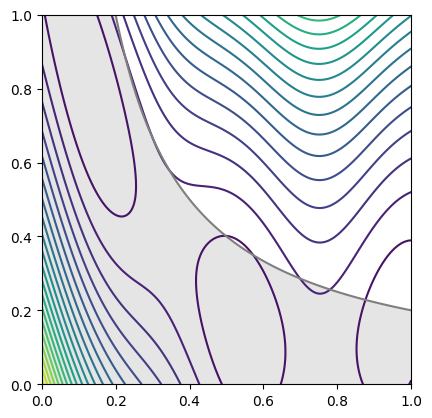

In [2]:
# defines the objective function to minimize
def modified_branin(x):
    X1 = 15 * x[0] - 5
    X2 = 15 * x[1]
    return (1*(X2-(5.1/(4*np.pi**2))*X1**2+(5/np.pi)*X1-6)**2+10*(1-1/(8*np.pi))*np.cos(X1)+10)+5*x[0]

# defines the inequality constraint
def simple_constraint(x):
    return -x[0]*x[1] + 0.2

# defines the problem bounds
bounds = np.array([
    [0, 1],
    [0, 1],
])

XX, YY, Z = get_plot2d_data(modified_branin, bounds, 201)
_, _, C = get_plot2d_data(simple_constraint, bounds, 201)

fig, ax = plt.subplots()
ax.contour(XX, YY, Z, levels=25)
ax.contour(XX, YY, C, levels=[0], colors="C7")
ax.contourf(XX, YY, np.where(C<=0, np.nan, C), levels=0, colors="C7", alpha=0.2)
ax.set_aspect("equal")
plt.show()

### Starting the optimization

The easiest way to begin constrained Bayesian optimization is to use the `minimize` method. Three arguments must be provided:

- `objective`: the function to minimize;
- `design_space`: the function boundary;
- `constraints`: the constraint definitions.

Since the objective parameter expects a list, place the objective function in a list. Providing the design space argument with an `np.ndarray` assumes the design space is entirely continuous.

In the cell below, we first define the constraint. The optimization starts by calling the `minimize` method. This method returns a `State` object, from which we can retrieve the final DoE, as well as the best feasible objective value.

In [3]:
constraint = [
    {
        "fun": [simple_constraint],
        "upper": 0.,                    # equivalent to: g(x) <= 0
    }
]

state = minimize(
    [modified_branin],
    bounds,
    constraints=constraint,
    max_iter=10,
    driver_kwargs={"seed": 0},
)

          iter         budget           fmin           rscv       fidelity        gp_time       acq_time
             0              5    5.47552e+01      0.000e+00            nan            nan            nan
             1              6    5.47552e+01      0.000e+00              1          0.072          0.193
             2              7    4.44074e+01      0.000e+00              1          0.064          0.123
             3              8    3.23574e+01      0.000e+00              1          0.092          0.186
             4              9    3.23574e+01      0.000e+00              1          0.099          0.206
             5             10    3.23574e+01      0.000e+00              1          0.087          0.182
             6             11    9.03138e+00      0.000e+00              1          0.088          0.669
             7             12    6.66900e+00      3.359e-05              1          0.076          0.525
             8             13    6.66900e+00      3.359

We can retrieve the best function sample using the `get_best_sample` class method. This returns a `Sample` object containing data such as:

- `x`: the design point
- `obj`: the objective value at `x`
- `cstr`: the constraint values at `x`
- `eval_time`: the elapsed time to sample the objective and the constraints.

The `Sample` object also contains some metadata:

- `iter`: the iteration at which the function was sampled
- `budget`: the budget after sampling the function
- `rscv`: the Root Square Constraint Violation

Furthermore, the `get_best_sample` class method accepts a `ctol` argument which specify the maximum RSCV tolerated. In the code cell below, we demonstrate how the value passed to `ctol` affects the best sample returned.


In [4]:
print("####### high constraint tolerance -> returns a lower objective value #######")
best_sample = state.get_best_sample(ctol=1.)
print(best_sample)

print("####### low constraint tolerance -> returns a higher objective value #######")
best_sample = state.get_best_sample(ctol=1e-4)
print(best_sample)

####### high constraint tolerance -> returns a lower objective value #######
======= sample data =======
x =             [0.12739234 0.74589931]
obj =           [1.9711074]
cstr =          [0.10497814]
eval_time =     [2.55699979e-06 5.84000190e-07]
------- meta data -------
iter =     0
budget =     4
rscv =     0.10497814310624284

####### low constraint tolerance -> returns a higher objective value #######
======= sample data =======
x =             [0.97184886 0.20579225]
obj =           [5.59948174]
cstr =          [1.03207569e-06]
eval_time =     [7.94700009e-06 1.31700017e-06]
------- meta data -------
iter =     10
budget =     15
rscv =     1.0320756926307517e-06



### Plotting the results

The code snippet below exports all the design points evaluated during the optimization process and plots them against the test problem. The best sample is marked with a star.

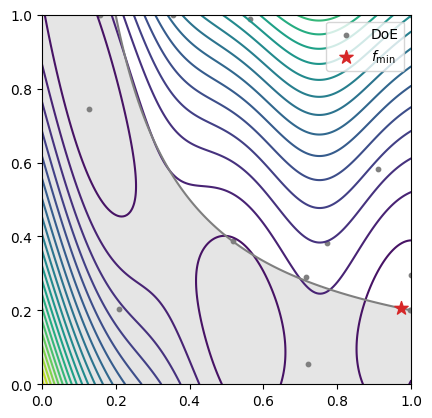

In [5]:
x_doe = state.dataset.export_as_dict()["x"]
y_doe = state.dataset.export_as_dict()["obj"]

fig, ax = plt.subplots()
ax.contour(XX, YY, Z, levels=25)
ax.contour(XX, YY, C, levels=[0], colors="C7")
ax.contourf(XX, YY, np.where(C<=0, np.nan, C), levels=0, colors="C7", alpha=0.2)

# plots all the design points evaluated
ax.scatter(x_doe[:, 0], x_doe[:, 1], color="C7", s=10, label="DoE")

# plots the best design point
ax.scatter(best_sample.x[0], best_sample.x[1], color="C3", marker="*", label=r"$f_\min$", s=100, zorder=50)

ax.legend()
ax.set_aspect("equal")
plt.show()

## Multiple constraints (equality and inequalities)

The following example illustrates how to set up an optimization problem with multiple constraint types. It shows how to optimize the Sasena test function with one equality constraint and two inequality constraints. The problem can be formulated as:

$$
\begin{aligned}
\min_{x\in\mathbb{R}^2} \quad & 2 + 0.01\,(x_2 - x_1^2)^2 + (1 - x_1)^2 + 2(2 - x_2)^2 + 7 \sin(0.5\,x_1)\sin(0.7\,x_1 x_2) \\
\text{s.t.} \quad
& 0 \leq x_i \leq 1 \quad i = 1, 2 \\
& -0.8 \leq -\sin\left(x_1 - x_2 - \frac{\pi}{8}\right) \leq 0.8 \\
& (x_1 - 2.5)^2 + (x_2 - 2.5)^2 = 0
\end{aligned}
$$


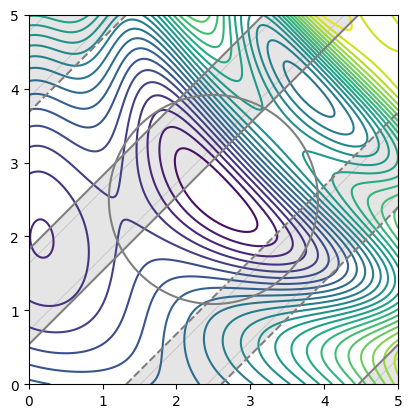

In [6]:
# defines the objective function to minimize
def sasena(x):
    return 2+0.01*(x[1]-x[0]**2)**2+(1-x[0])**2+2*(2-x[1])**2+7*np.sin(0.5*x[0])*np.sin(0.7*x[0]*x[1])

# defines the equality constraint
def eq_constraint(x):
    return (x[0]-2.5)**2+(x[1]-2.5)**2-2

# defines the inequality constraint
def ineq_constraint(x):
    return -np.sin(x[0]-x[1]-np.pi/8)

# defines the problem bounds
bounds = np.array([
    [0, 5],
    [0, 5]
])

XX, YY, Z = get_plot2d_data(sasena, bounds, 201)
_, _, C_eq = get_plot2d_data(eq_constraint, bounds, 201)
_, _, C_ineq = get_plot2d_data(ineq_constraint, bounds, 201)

fig, ax = plt.subplots()
# draws the objective
ax.contour(XX, YY, Z, levels=25)
# draws equality constraint
ax.contour(XX, YY, C_eq, levels=[0], colors="C7")
# draws the inequality constraints
ax.contour(XX, YY, C_ineq, levels=[-0.8, 0.8], colors="C7")
ax.contourf(XX, YY, np.where(C_ineq<=0.8, np.nan, C_ineq), levels=0, colors="C7", alpha=0.2)
ax.contourf(XX, YY, np.where(C_ineq>=-0.8, np.nan, C_ineq), levels=0, colors="C7", alpha=0.2)
ax.set_aspect("equal")
plt.show()


### Starting the optimization

The first step is to define the constraints using a list of dictionaries. Each dictionary specifies the constraint callable and the feasible bounds.

- For an equality constraint, the "equal" key sets the value at which the constraint must equal.
- For an inequality constraint, the keywords "lower" and "upper" correspond to the lower and upper bounds that define the feasible domain.

Note that even if the problem is defined with only two constraint functions, there are actually three constraints in total (one for the equality and two for the inequalities). A single surrogate model will be generated for both inequality constraints, effectively using a single model to represent the lower and upper bounds.

In [7]:
constraints = [
    {
        "fun": [eq_constraint],
        "equal": 0.                 # equivalent to: g(x) == 0.
    },
    {
        "fun": [ineq_constraint],
        "lower": -0.8,              # equivalent to: g(x) >= -0.8
        "upper": 0.8,               # equivalent to: g(x) <= 0.8
    }
]

state = minimize(
    [sasena],
    bounds,
    constraints=constraints,
    max_iter=20,
    driver_kwargs={"seed": 0},
)

          iter         budget           fmin           rscv       fidelity        gp_time       acq_time
             0              5    6.28530e+00      2.329e+00            nan            nan            nan
             1              6    6.28530e+00      2.329e+00              1          0.083          0.626
             2              7    6.41145e+00      2.239e+00              1          0.079          1.385
             3              8    7.53833e+00      1.489e+00              1          0.096          0.395
             4              9    9.60108e+00      4.334e-01              1          0.113          1.116
             5             10    1.18833e+01      1.345e-01              1          0.097          0.696
             6             11    7.23622e+00      4.880e-03              1          0.099          0.475
             7             12    7.23622e+00      4.880e-03              1          0.106          1.591
             8             13    6.38624e+00      6.444

### Plotting the results

The code snippet below exports all the design points evaluated during the optimization process and plots them against the test problem. The best sample is marked with a star.

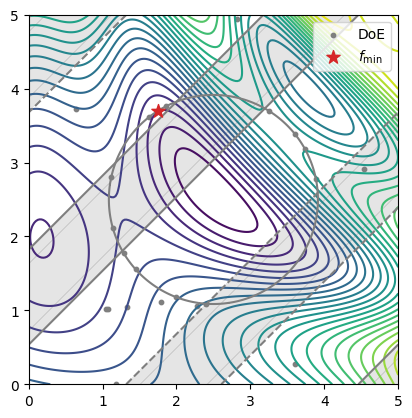

In [8]:
# retrieves the best sample with respect to a constraint tolerance
best_sample = state.get_best_sample(ctol=1e-6)

# retrieves the entire Design of Experiment (DoE)
x_doe = state.dataset.export_as_dict()["x"]

fig, ax = plt.subplots()
# draws the objective
ax.contour(XX, YY, Z, levels=25)
# draws equality constraint
ax.contour(XX, YY, C_eq, levels=[0], colors="C7")
# draws the inequality constraints
ax.contour(XX, YY, C_ineq, levels=[-0.8, 0.8], colors="C7")
ax.contourf(XX, YY, np.where(C_ineq<=0.8, np.nan, C_ineq), levels=0, colors="C7", alpha=0.2)
ax.contourf(XX, YY, np.where(C_ineq>=-0.8, np.nan, C_ineq), levels=0, colors="C7", alpha=0.2)

# plots all the design points evaluated
ax.scatter(x_doe[:, 0], x_doe[:, 1], color="C7", s=10, label="DoE")

# plots the best design point
ax.scatter(best_sample.x[0], best_sample.x[1], color="C3", marker="*", label=r"$f_\min$", s=100, zorder=50)

ax.legend()
ax.set_aspect("equal")
plt.show()
